In [7]:
import pandas as pd

# 1. Dosya yolunu data klasörünü gösterecek şekilde güncelliyoruz
df = pd.read_csv('../data/raw/train.csv') 

# 2. Temizlik işlemleri için bir kopyasını oluşturuyoruz
df_clean = df.copy()

# Başarıyla kopyalandığını teyit edelim
df_clean.head(3)

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied


### Removing Irrelevant Features

In [ ]:
df_clean.drop(columns=["Unnamed: 0", "id"], inplace=True) 

"Unnamed: 0" ve "id" sütunları istatistiksel analiz için anlamlı bilgi sağlamadıkları için kaldırıldı.

### Standardizing Column Names

In [9]:
# 1. Tüm harfleri küçült
# 2. Boşlukları alt çizgi yap
# 3. Eğik çizgi (/) işaretlerini alt çizgi yap
# 4. Tire (-) işaretlerini alt çizgi yap

df_clean.columns = (
    df_clean.columns
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('/', '_')
    .str.replace('-', '_')
)

# sütun isimlerini yazdıralım:

print(df_clean.columns)


Index(['gender', 'customer_type', 'age', 'type_of_travel', 'class',
       'flight_distance', 'inflight_wifi_service',
       'departure_arrival_time_convenient', 'ease_of_online_booking',
       'gate_location', 'food_and_drink', 'online_boarding', 'seat_comfort',
       'inflight_entertainment', 'on_board_service', 'leg_room_service',
       'baggage_handling', 'checkin_service', 'inflight_service',
       'cleanliness', 'departure_delay_in_minutes', 'arrival_delay_in_minutes',
       'satisfaction'],
      dtype='object')


Veri seti üzerinde yapılan incelemede, sütun isimlerinin büyük/küçük harf tutarsızlıkları, boşluklar ve özel karakterler ('/', '-') içerdiği görülmüştür (Örn: `Customer Type`, `Departure/Arrival time convenient`). 

Veri manipülasyonu ve makine öğrenmesi modelleme aşamalarında kod okunabilirliğini artırmak, sözdizimi (syntax) hatalarını önlemek ve metodolojik standartları sağlamak amacıyla tüm sütun isimleri **"snake_case"** formatına dönüştürülmüştür.

**Uygulanan Dönüşümler:**
* Tüm harfler küçük harf formatına (`lower()`) dönüştürüldü.
* İsimler arasındaki boşluklar, tire (`-`) ve eğik çizgi (`/`) işaretleri, alt çizgi (`_`) ile değiştirildi.


### Data Type Optimization

In [10]:
# Kategorik (metin içeren) sütunları seçiyoruz
kategorik_sutunlar = ['gender', 'customer_type', 'type_of_travel', 'class', 'satisfaction']

# Bir döngü ile hepsini tek tek 'category' tipine dönüştürüyoruz
for sutun in kategorik_sutunlar:
    df_clean[sutun] = df_clean[sutun].astype('category')

df_clean.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype   
---  ------                             --------------   -----   
 0   gender                             103904 non-null  category
 1   customer_type                      103904 non-null  category
 2   age                                103904 non-null  int64   
 3   type_of_travel                     103904 non-null  category
 4   class                              103904 non-null  category
 5   flight_distance                    103904 non-null  int64   
 6   inflight_wifi_service              103904 non-null  int64   
 7   departure_arrival_time_convenient  103904 non-null  int64   
 8   ease_of_online_booking             103904 non-null  int64   
 9   gate_location                      103904 non-null  int64   
 10  food_and_drink                     103904 non-null  int64   
 11  online_boarding           


Veri manipülasyonu aşamasında bellek (RAM) kullanımını minimize etmek ve ilerleyen fazlarda kurulacak makine öğrenmesi algoritmalarının eğitim hızını artırmak hedeflenmiştir. 

Bu doğrultuda, az sayıda farklı eşsiz değere sahip metinsel özellikler (`object` tipindeki sütunlar), istatistiksel modelleme prensiplerine uygun olarak `category` veri tipine dönüştürülmüştür. Bu işlem sayesinde veri setinin sistem üzerindeki yükü ciddi oranda hafifletilmiştir.

### Checking Duplicate Records

In [11]:
# Önce veri setinde birbirinin tamamen aynısı kaç satır var onu bulalım
kopya_sayisi = df_clean.duplicated().sum()
print(f"Tespit edilen kopya satır sayısı: {kopya_sayisi}")

# Eğer kopya satır varsa, bunları veri setinden kalıcı olarak siliyoruz
df_clean.drop_duplicates(inplace=True)

# Temizlik sonrası elimizde kalan net satır sayısını kontrol edelim
print(f"Güncel ve temizlenmiş satır sayımız: {len(df_clean)}")

Tespit edilen kopya satır sayısı: 0
Güncel ve temizlenmiş satır sayımız: 103904


Makine öğrenmesi modellerinde aşırı öğrenmeye ve algoritmik yanlılığa sebep olabilecek mükerrer kayıtlar `df.duplicated()` metodu ile incelenmiştir.

**Sonuç ve Çıkarım:**
Yapılan tarama sonucunda veri setinde **0 adet kopya satır** tespit edilmiştir. Mevcut 103.904 satırın tamamının unique olduğu doğrulanmıştır.Bu sonuç sayesinde herhangi bir satır silme işlemine gerek kalmadan bir sonraki analitik aşamaya geçilmiştir.

### Investigating Zero Values in Service Rating Variables

In [13]:
# 1-5 arası puanlama içeren anket sütunlarının listesi

anket_sutunlari = [
    'inflight_wifi_service', 'departure_arrival_time_convenient', 'ease_of_online_booking',
    'gate_location', 'food_and_drink', 'online_boarding', 'seat_comfort',
    'inflight_entertainment', 'on_board_service', 'leg_room_service',
    'baggage_handling', 'checkin_service', 'inflight_service', 'cleanliness'
]

# Her sütundaki '0' sayısını hesaplayıp ekrana yazdıralım
 
print("Anket Sütunlarındaki '0' Değerlerinin Sayısı:\n" + "-"*45)
for sutun in anket_sutunlari:
    sifir_sayisi = (df_clean[sutun] == 0).sum()
    if sifir_sayisi > 0:
        print(f"{sutun}: {sifir_sayisi} adet '0' içeriyor.")

Anket Sütunlarındaki '0' Değerlerinin Sayısı:
---------------------------------------------
inflight_wifi_service: 3103 adet '0' içeriyor.
departure_arrival_time_convenient: 5300 adet '0' içeriyor.
ease_of_online_booking: 4487 adet '0' içeriyor.
gate_location: 1 adet '0' içeriyor.
food_and_drink: 107 adet '0' içeriyor.
online_boarding: 2428 adet '0' içeriyor.
seat_comfort: 1 adet '0' içeriyor.
inflight_entertainment: 14 adet '0' içeriyor.
on_board_service: 3 adet '0' içeriyor.
leg_room_service: 472 adet '0' içeriyor.
checkin_service: 1 adet '0' içeriyor.
inflight_service: 3 adet '0' içeriyor.
cleanliness: 12 adet '0' içeriyor.


Veri seti üzerinde yapılan incelemelerde, hizmet kalitesini ölçen bazı anket değişkenlerinde 0 değerleri bulunduğu gözlemlenmiştir.


Özellikle departure_arrival_time_convenient, ease_of_online_booking ve inflight_wifi_service değişkenlerinde binlerce 0 değeri bulunurken, seat_comfort, gate_location ve checkin_service gibi değişkenlerde yalnızca birkaç adet 0 değeri bulunmaktadır.

Bu durum, 0 değerlerinin tüm değişkenlerde aynı anlamı taşımayabileceğini göstermektedir. Veri seti dokümantasyonunda bu değerlerin anlamı açık biçimde belirtilmediğinden, analiz sürecinde herhangi bir veri doldurma işlemi uygulanmamış ve orijinal değerler korunmuştur.


### Missing Value Handling

Before performing any statistical analysis, missing values were examined to determine their extent and potential impact on the dataset.

In [17]:
df_clean.isnull().sum()

gender                                 0
customer_type                          0
age                                    0
type_of_travel                         0
class                                  0
flight_distance                        0
inflight_wifi_service                  0
departure_arrival_time_convenient      0
ease_of_online_booking                 0
gate_location                          0
food_and_drink                         0
online_boarding                        0
seat_comfort                           0
inflight_entertainment                 0
on_board_service                       0
leg_room_service                       0
baggage_handling                       0
checkin_service                        0
inflight_service                       0
cleanliness                            0
departure_delay_in_minutes             0
arrival_delay_in_minutes             310
satisfaction                           0
dtype: int64

In [20]:
missing_percentage = (df_clean.isnull().sum() / len(df_clean)) * 100

missing_percentage[missing_percentage > 0]

arrival_delay_in_minutes    0.298352
dtype: float64

**Gözlem:** `Arrival Delay in Minutes` sütununda 310 eksik değer var (%0.298), bu oldukça düşük bir oran. 
Bu kadar küçük bir oranda satırları silmek veri kaybına yol açsa da veri setinin genelini etkilemez.

In [28]:
# Arrival Delay eksik olan satırlarda Departure Delay ne durumda?
missing_rows = df_clean[df_clean['arrival_delay_in_minutes'].isnull()]

print("Eksik satırlardaki Departure Delay istatistikleri:")
print(missing_rows['departure_delay_in_minutes'].describe())

print("\nTüm veri setindeki Departure Delay istatistikleri:")
print(df_clean['departure_delay_in_minutes'].describe())

Eksik satırlardaki Departure Delay istatistikleri:
count    310.000000
mean      37.432258
std       62.239283
min        0.000000
25%        0.000000
50%        8.000000
75%       47.500000
max      455.000000
Name: departure_delay_in_minutes, dtype: float64

Tüm veri setindeki Departure Delay istatistikleri:
count    103904.000000
mean         14.815618
std          38.230901
min           0.000000
25%           0.000000
50%           0.000000
75%          12.000000
max        1592.000000
Name: departure_delay_in_minutes, dtype: float64


arrival_delay_in_minutes değişkeninde bulunan eksik değerler için doğrudan bir doldurma yöntemi uygulanmamış, öncelikle bu gözlemler ayrıntılı olarak incelenmiştir.

Bu amaçla, varış gecikmesi eksik olan yolcuların kalkış gecikmesi (departure_delay_in_minutes) değerleri veri setinin genel dağılımı ile karşılaştırılmıştır. Böylece eksik gözlemlerin veri setinin genel yapısından belirgin şekilde farklı olup olmadığı değerlendirilmiştir.

Ayrıca, kalkış gecikmesi ile varış gecikmesi arasındaki ilişki korelasyon analizi ile incelenmiştir. Bu analiz, eksik değerlerin doldurulmasında departure_delay_in_minutes değişkeninin güvenilir bir referans olarak kullanılıp kullanılamayacağını değerlendirmek amacıyla gerçekleştirilmiştir.

In [30]:
df_clean[['departure_delay_in_minutes', 'arrival_delay_in_minutes']].corr()

,departure_delay_in_minutes,arrival_delay_in_minutes
departure_delay_in_minutes,1.000000,0.965481
arrival_delay_in_minutes,0.965481,1.000000


Korelasyon analizi sonucunda departure_delay_in_minutes ile arrival_delay_in_minutes değişkenleri arasında 0.965 korelasyon katsayısı elde edilmiştir.

Bu değer, iki değişken arasında çok güçlü pozitif bir ilişki bulunduğunu göstermektedir. Başka bir ifadeyle, kalkışta yaşanan gecikmeler büyük ölçüde varış gecikmelerine de yansımaktadır.

Bu nedenle, arrival_delay_in_minutes değişkenindeki eksik değerlerin aynı satırdaki departure_delay_in_minutes değerleri kullanılarak doldurulması hem operasyonel açıdan anlamlı hem de istatistiksel olarak güçlü bir yaklaşımdır.

In [ ]:
df_clean["arrival_delay_in_minutes"] = (df_clean["arrival_delay_in_minutes"].fillna(df_clean["departure_delay_in_minutes"]))

In [32]:
df_clean.isnull().sum()

gender                               0
customer_type                        0
age                                  0
type_of_travel                       0
class                                0
flight_distance                      0
inflight_wifi_service                0
departure_arrival_time_convenient    0
ease_of_online_booking               0
gate_location                        0
food_and_drink                       0
online_boarding                      0
seat_comfort                         0
inflight_entertainment               0
on_board_service                     0
leg_room_service                     0
baggage_handling                     0
checkin_service                      0
inflight_service                     0
cleanliness                          0
departure_delay_in_minutes           0
arrival_delay_in_minutes             0
satisfaction                         0
dtype: int64

Doldurma işlemi sonrasında veri setinde eksik değer kalmamıştır. Böylece veri seti, keşifsel veri analizi ve istatistiksel analizler için eksiksiz hale getirilmiştir.

### AYKIRI DEĞER ANALİZİ

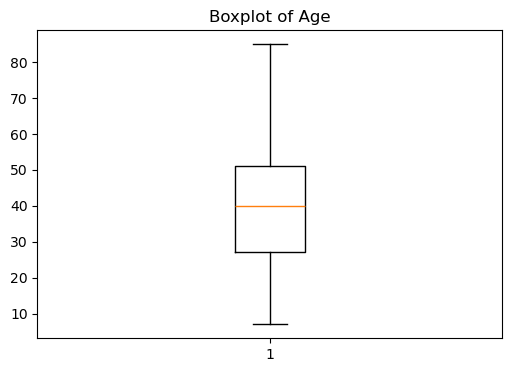

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.boxplot(df_clean["age"])
plt.title("Boxplot of Age")
plt.show()


In [56]:
Q1 = df_clean["age"].quantile(0.25)
Q3 = df_clean["age"].quantile(0.75)

IQR = Q3 - Q1

lower_age = Q1 - 1.5 * IQR
upper_age = Q3 + 1.5 * IQR

In [78]:
age_outliers = df_clean[
    (df_clean["age"] < lower_age) |
    (df_clean["age"] > upper_age)
]

len(age_outliers)
print(f"Age Outliers: {len(age_outliers)}")
print(f"Alt Sınır: {lower_age}")
print(f"Üst Sınır: {upper_age}")

Age Outliers: 0
Alt Sınır: -9.0
Üst Sınır: 87.0


In [58]:
len(age_outliers) / len(df_clean) * 100

0.0

Age Değişkeni İçin Aykırı Değer Analizi

age değişkeni Boxplot ve IQR yöntemi kullanılarak incelenmiştir. Hesaplanan alt ve üst sınırlar içerisinde tüm gözlemlerin yer aldığı görülmüştür. Bu nedenle yaş değişkeninde IQR yöntemine göre aykırı değer tespit edilmemiştir ve herhangi bir veri temizleme işlemi uygulanmamıştır.

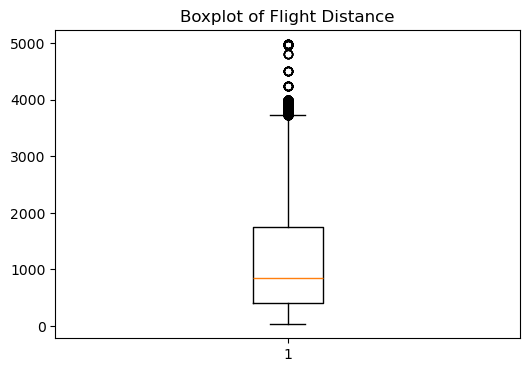

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.boxplot(df_clean["flight_distance"])
plt.title("Boxplot of Flight Distance")
plt.show()

In [60]:
Q1 = df_clean["flight_distance"].quantile(0.25)
Q3 = df_clean["flight_distance"].quantile(0.75)

IQR = Q3 - Q1

lower_flight_distance = Q1 - 1.5 * IQR
upper_flight_distance = Q3 + 1.5 * IQR

In [77]:
flight_distance_outliers = df_clean[
    (df_clean["flight_distance"] < lower_flight_distance) |
    (df_clean["flight_distance"] > upper_flight_distance)
]

len(flight_distance_outliers)
print(f"Flight Distance Outliers: {len(flight_distance_outliers)}")
print(f"Alt Sınır: {lower_flight_distance}")
print(f"Üst Sınır: {upper_flight_distance}")

Flight Distance Outliers: 2291
Alt Sınır: -1579.5
Üst Sınır: 3736.5


In [69]:
len(flight_distance_outliers) / len(df_clean) * 100

2.2049199260856174

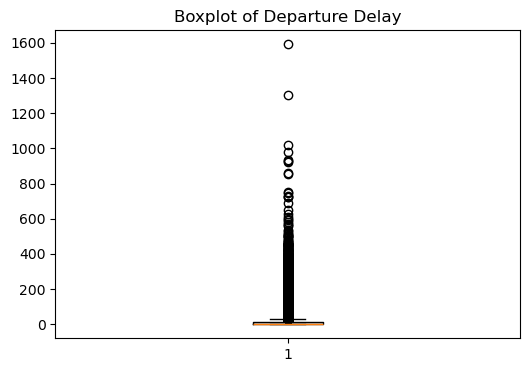

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.boxplot(df_clean["departure_delay_in_minutes"])
plt.title("Boxplot of Departure Delay")
plt.show()

In [62]:
Q1 = df_clean["departure_delay_in_minutes"].quantile(0.25)
Q3 = df_clean["departure_delay_in_minutes"].quantile(0.75)

IQR = Q3 - Q1

lower_departure_delay = Q1 - 1.5 * IQR
upper_departure_delay = Q3 + 1.5 * IQR

In [76]:
departure_delay_outliers = df_clean[
    (df_clean["departure_delay_in_minutes"] < lower_departure_delay) |
    (df_clean["departure_delay_in_minutes"] > upper_departure_delay)
]

len(departure_delay_outliers)
print(f"Departure Delay Outliers: {len(departure_delay_outliers)}")
print(f"Alt Sınır: {lower_departure_delay}")
print(f"Üst Sınır: {upper_departure_delay}")

Departure Delay Outliers: 14529
Alt Sınır: -18.0
Üst Sınır: 30.0


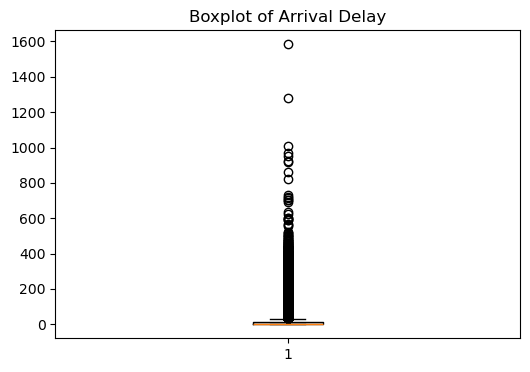

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.boxplot(df_clean["arrival_delay_in_minutes"])
plt.title("Boxplot of Arrival Delay")
plt.show()

In [64]:
Q1 = df_clean["arrival_delay_in_minutes"].quantile(0.25)
Q3 = df_clean["arrival_delay_in_minutes"].quantile(0.75)

IQR = Q3 - Q1

lower_arrival_delay = Q1 - 1.5 * IQR
upper_arrival_delay = Q3 + 1.5 * IQR

In [75]:
arrival_delay_outliers = df_clean[
    (df_clean["arrival_delay_in_minutes"] < lower_arrival_delay) |
    (df_clean["arrival_delay_in_minutes"] > upper_arrival_delay)
]

len(arrival_delay_outliers)
print(f"Arrival Delay Outliers: {len(arrival_delay_outliers)}")
print(f"Alt Sınır: {lower_arrival_delay}")
print(f"Üst Sınır: {upper_arrival_delay}")

Arrival Delay Outliers: 14052
Alt Sınır: -19.5
Üst Sınır: 32.5


In [68]:
len(arrival_delay_outliers) / len(df_clean) * 100

13.524022174314752